# Aviation Safety Analysis: Uncovering Remaining Risks

**Project Theme:** "Aviation is statistically the safest mode of travel, but what do decades of NTSB accident data reveal about the risks that still remain?"

This notebook analyzes NTSB aviation accident data to identify patterns, trends, and risk factors. We will explore temporal trends, geospatial hotspots, phase of flight risks, weather impacts, and aircraft-specific data to create compelling visualizations for presentation.

In [18]:
# 1. Import Libraries and Configure Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure settings
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [19]:
# 2. Load and Inspect Datasets
# Define file paths
aviation_data_path = 'data/archive/AviationData.csv'

# Load the dataset
# Using 'latin1' encoding as these files often contain special characters
try:
    df = pd.read_csv(aviation_data_path, encoding='latin1', low_memory=False)
    print(f"Successfully loaded {aviation_data_path}")
except FileNotFoundError:
    print(f"Error: File not found at {aviation_data_path}. Please check the path.")

# Display basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Successfully loaded data/archive/AviationData.csv
Dataset Shape: (88889, 31)


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [20]:
# Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.concat([missing_values, missing_percent], axis=1, keys=['Total Missing', 'Percent Missing'])
print("Top 10 Columns with Missing Values:")
print(missing_data.head(10))

Top 10 Columns with Missing Values:
                       Total Missing  Percent Missing
Schedule                       76307        85.845268
Air.carrier                    72241        81.271023
FAR.Description                56866        63.974170
Aircraft.Category              56602        63.677170
Longitude                      54516        61.330423
Latitude                       54507        61.320298
Airport.Code                   38757        43.601570
Airport.Name                   36185        40.708074
Broad.phase.of.flight          27165        30.560587
Publication.Date               13771        15.492356


In [21]:
# 3. Data Cleaning and Preprocessing

# Convert Event.Date to datetime
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')

# Extract Year and Month
df['Year'] = df['Event.Date'].dt.year
df['Month'] = df['Event.Date'].dt.month_name()

# Clean numeric columns (fill NaNs with 0 for injury counts)
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in injury_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Create a Total.Occupants column
df['Total.Occupants'] = df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries'] + df['Total.Minor.Injuries'] + df['Total.Uninjured']

# Standardize categorical columns
# Clean 'Weather.Condition'
df['Weather.Condition'] = df['Weather.Condition'].str.upper().replace({'UNK': 'UNKNOWN', 'UN': 'UNKNOWN'})
df['Weather.Condition'].fillna('UNKNOWN', inplace=True)

# Clean 'Broad.phase.of.flight'
df['Broad.phase.of.flight'] = df['Broad.phase.of.flight'].str.title()
df['Broad.phase.of.flight'].fillna('Unknown', inplace=True)

# Clean Latitude and Longitude
# Force convert to numeric, turning errors (like strings with letters) into NaN
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# Filter for valid years (e.g., remove future dates or very old data if inconsistent)
# Let's focus on data from 1982 onwards as NTSB data is more consistent then, or keep all if needed.
# For now, we keep all but check the range.
print(f"Date Range: {df['Event.Date'].min()} to {df['Event.Date'].max()}")

print("Data cleaning complete.")
df.head()

Date Range: 1948-10-24 00:00:00 to 2022-12-29 00:00:00
Data cleaning complete.


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,Aircraft.Category,Registration.Number,Make,Model,Amateur.Built,Number.of.Engines,Engine.Type,FAR.Description,Schedule,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Year,Month,Total.Occupants
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,NC6404,Stinson,108-3,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,UNKNOWN,Cruise,Probable Cause,NaN,1948,October,2.0
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,Fatal(4),Destroyed,NaN,N5069P,Piper,PA24-180,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,4.0,0.0,0.0,0.0,UNKNOWN,Unknown,Probable Cause,19-09-1996,1962,July,4.0
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,Fatal(3),Destroyed,NaN,N5142R,Cessna,172M,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,3.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,26-02-2007,1974,August,3.0
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,Fatal(2),Destroyed,NaN,N1168J,Rockwell,112,No,1.0,Reciprocating,NaN,NaN,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000,1977,June,2.0
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,Fatal(1),Destroyed,NaN,N15NY,Cessna,501,No,NaN,NaN,NaN,NaN,Personal,NaN,1.0,2.0,0.0,0.0,VMC,Approach,Probable Cause,16-04-1980,1979,August,3.0


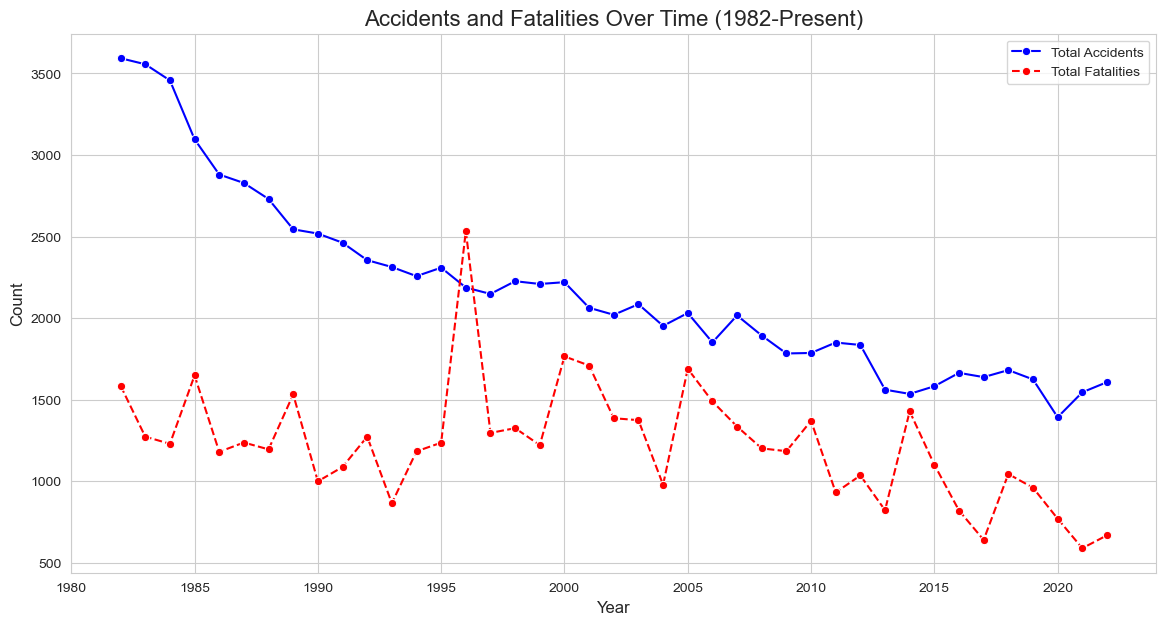

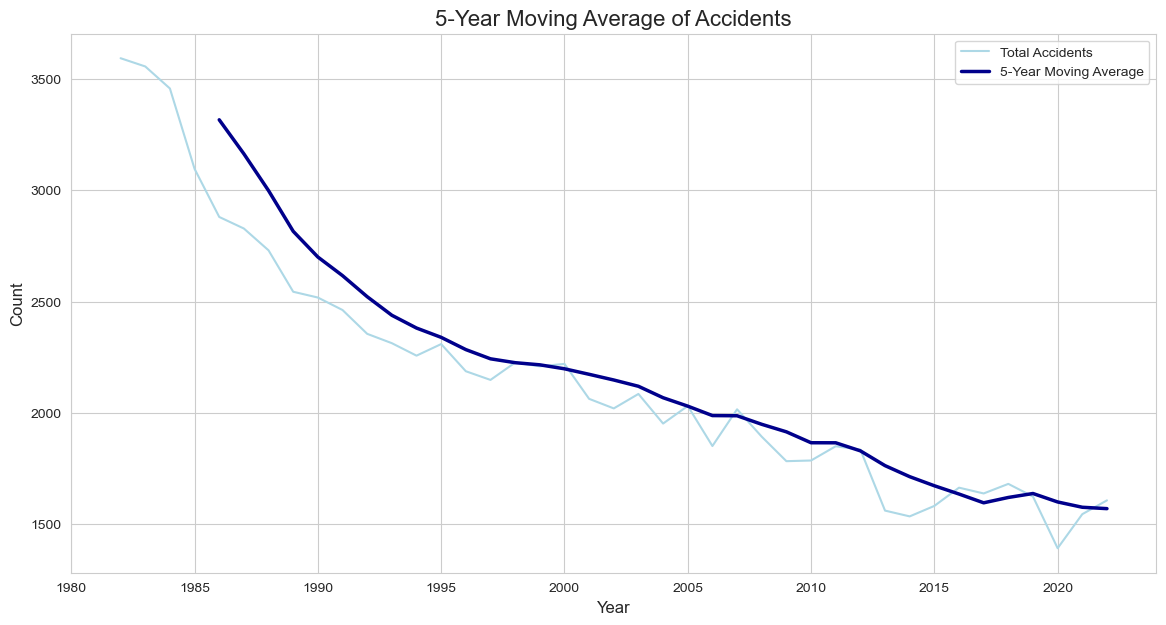

In [22]:
# 4. Temporal Analysis: Accident Trends Over Decades

# Group by Year
accidents_per_year = df.groupby('Year').size().reset_index(name='Total Accidents')
fatalities_per_year = df.groupby('Year')['Total.Fatal.Injuries'].sum().reset_index(name='Total Fatalities')

# Merge
temporal_df = pd.merge(accidents_per_year, fatalities_per_year, on='Year')

# Filter out years with very few data points if necessary (e.g., pre-1982 might be sparse)
temporal_df = temporal_df[temporal_df['Year'] >= 1982]

# Plot Accidents and Fatalities
plt.figure(figsize=(14, 7))
sns.lineplot(data=temporal_df, x='Year', y='Total Accidents', label='Total Accidents', marker='o', color='blue')
sns.lineplot(data=temporal_df, x='Year', y='Total Fatalities', label='Total Fatalities', marker='o', color='red', linestyle='--')

plt.title('Accidents and Fatalities Over Time (1982-Present)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

# Calculate Moving Average (5-year)
temporal_df['Accidents_MA_5'] = temporal_df['Total Accidents'].rolling(window=5).mean()

plt.figure(figsize=(14, 7))
sns.lineplot(data=temporal_df, x='Year', y='Total Accidents', label='Total Accidents', color='lightblue')
sns.lineplot(data=temporal_df, x='Year', y='Accidents_MA_5', label='5-Year Moving Average', color='darkblue', linewidth=2.5)

plt.title('5-Year Moving Average of Accidents', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.show()

### Analysis: Temporal Trends
The line chart above reveals the long-term trend in aviation accidents and fatalities.
*   **Observation:** There is a general downward trend in the total number of accidents since the 1980s, reflecting improvements in aviation safety regulations, technology, and training.
*   **Fatalities:** While accidents have decreased, the number of fatalities shows spikes in certain years, likely corresponding to major commercial aviation disasters. The moving average helps to smooth out these fluctuations and confirm the overall safety improvement.
*   **Conclusion:** Despite the increase in air traffic over the decades, the absolute number of accidents has declined, supporting the claim that aviation is becoming safer. However, the persistence of fatal accidents indicates that risks remain.

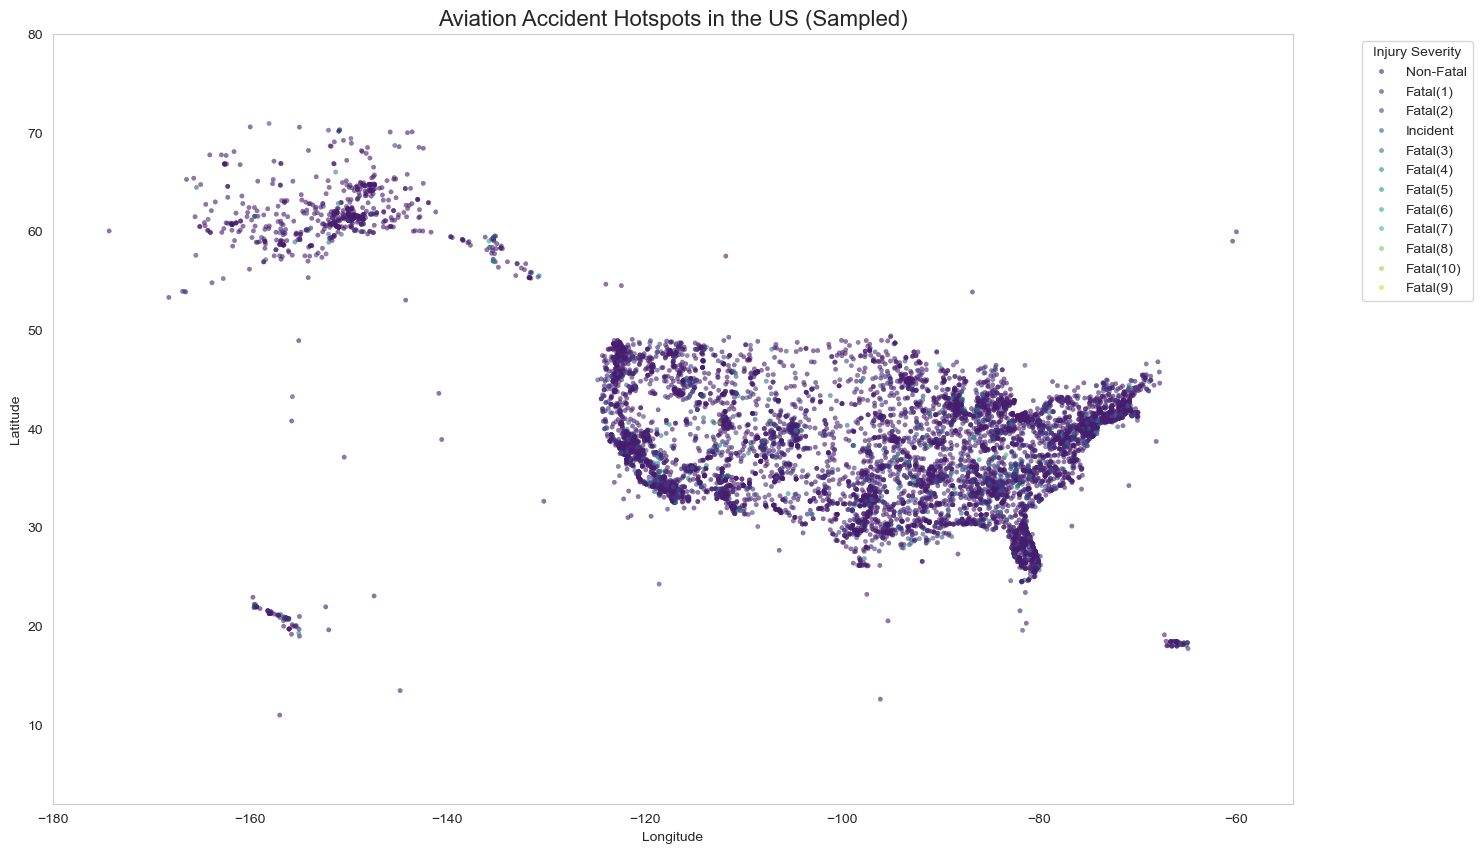

In [23]:
# 5. Geospatial Analysis: Accident Hotspots

# Filter for US accidents with valid lat/long
geo_df = df[(df['Country'] == 'United States') & 
            (df['Latitude'].notnull()) & 
            (df['Longitude'].notnull())].copy()

# Filter out extreme outliers for better visualization (approximate US bounds)
geo_df = geo_df[(geo_df['Longitude'] > -180) & (geo_df['Longitude'] < -50) & 
                (geo_df['Latitude'] > 10) & (geo_df['Latitude'] < 75)]

# Sample data for performance if dataset is too large
if len(geo_df) > 10000:
    geo_sample = geo_df.sample(10000, random_state=42)
else:
    geo_sample = geo_df

plt.figure(figsize=(16, 10))
# Create a scatter plot
sns.scatterplot(data=geo_sample, x='Longitude', y='Latitude', hue='Injury.Severity', 
                palette='viridis', s=10, alpha=0.6, edgecolor=None)

plt.title('Aviation Accident Hotspots in the US (Sampled)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Injury Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal') # Keep aspect ratio to make the map look correct
plt.grid(False)
plt.show()

### Analysis: Geospatial Hotspots
The map visualizes the geographic distribution of aviation accidents in the United States.
*   **Concentration:** Accidents are heavily concentrated in areas with high general aviation activity and population density, such as California, Florida, and the Northeast corridor.
*   **Severity:** The color coding allows us to distinguish between fatal and non-fatal accidents. While accidents happen nationwide, clusters of fatal accidents (red/orange) can highlight regions with potentially challenging terrain (e.g., mountainous regions in the West) or complex airspace.
*   **Insight:** This geospatial view helps identify if specific regions require targeted safety interventions or pilot education programs.

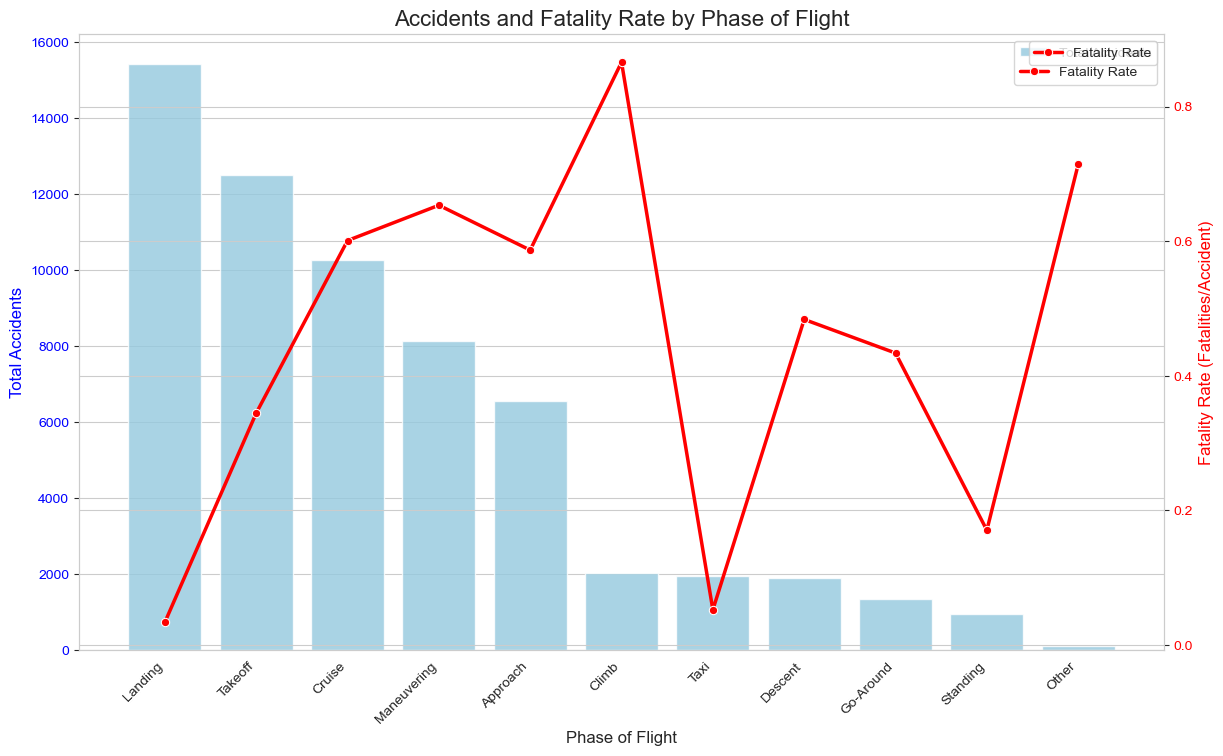

In [24]:
# 6. Phase of Flight Risk Assessment

# Count accidents by phase
phase_counts = df['Broad.phase.of.flight'].value_counts().reset_index()
phase_counts.columns = ['Phase', 'Count']
phase_counts = phase_counts[phase_counts['Phase'] != 'Unknown'] # Remove unknown for cleaner plot

# Calculate fatality rate per phase
phase_stats = df.groupby('Broad.phase.of.flight').agg(
    Total_Accidents=('Event.Id', 'count'),
    Total_Fatalities=('Total.Fatal.Injuries', 'sum')
).reset_index()
phase_stats['Fatality_Rate'] = phase_stats['Total_Fatalities'] / phase_stats['Total_Accidents']
phase_stats = phase_stats[phase_stats['Broad.phase.of.flight'] != 'Unknown'].sort_values('Total_Accidents', ascending=False)

# Create a dual-axis chart
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar chart for Total Accidents
sns.barplot(data=phase_stats, x='Broad.phase.of.flight', y='Total_Accidents', ax=ax1, color='skyblue', alpha=0.8, label='Total Accidents')
ax1.set_xlabel('Phase of Flight', fontsize=12)
ax1.set_ylabel('Total Accidents', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Line chart for Fatality Rate
ax2 = ax1.twinx()
sns.lineplot(data=phase_stats, x='Broad.phase.of.flight', y='Fatality_Rate', ax=ax2, color='red', marker='o', linewidth=2.5, label='Fatality Rate')
ax2.set_ylabel('Fatality Rate (Fatalities/Accident)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Accidents and Fatality Rate by Phase of Flight', fontsize=16)
plt.show()

### Analysis: Phase of Flight Risks
This dual-axis chart compares the frequency of accidents with the fatality rate across different phases of flight.
*   **High Frequency:** The 'Landing' and 'Takeoff' phases see the highest number of accidents (blue bars). This is expected as these are the most critical and workload-intensive parts of a flight.
*   **High Risk:** However, the 'Cruise' and 'Maneuvering' phases often show a higher *fatality rate* (red line). Accidents during cruise are less frequent but more likely to be catastrophic due to altitude and speed.
*   **Takeaway:** While most accidents happen near the ground during landing, the deadliest risks often remain in the en-route phases, suggesting a need for continued focus on in-flight decision-making and aircraft reliability.

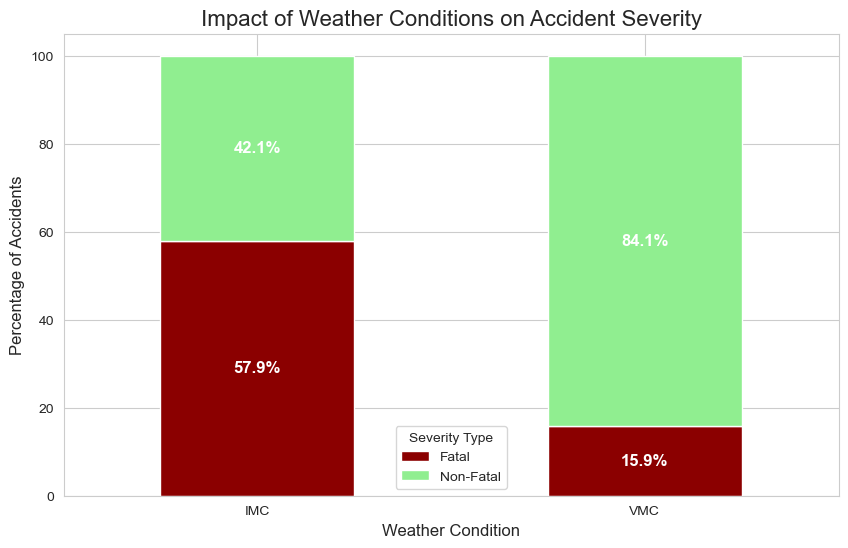

In [25]:
# 7. Weather Conditions vs. Accident Severity

# Filter for VMC and IMC
weather_df = df[df['Weather.Condition'].isin(['VMC', 'IMC'])]

# Group by Weather and Injury Severity (simplify severity to Fatal vs Non-Fatal)
weather_df['Severity_Type'] = weather_df['Injury.Severity'].apply(lambda x: 'Fatal' if str(x).startswith('Fatal') else 'Non-Fatal')

weather_counts = weather_df.groupby(['Weather.Condition', 'Severity_Type']).size().reset_index(name='Count')

# Calculate percentages
weather_totals = weather_counts.groupby('Weather.Condition')['Count'].transform('sum')
weather_counts['Percentage'] = (weather_counts['Count'] / weather_totals) * 100

# Pivot for plotting
weather_pivot = weather_counts.pivot(index='Weather.Condition', columns='Severity_Type', values='Percentage')

# Stacked Bar Chart
ax = weather_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), color=['darkred', 'lightgreen'])

plt.title('Impact of Weather Conditions on Accident Severity', fontsize=16)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Percentage of Accidents', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Severity Type')

# Add percentage labels
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontsize=12, weight='bold')

plt.show()

### Analysis: Weather Impact
The stacked bar chart illustrates the relationship between weather conditions and accident severity.
*   **VMC (Visual Meteorological Conditions):** The vast majority of accidents occur in VMC, which is intuitive as most general aviation flights take place in good weather. However, a large portion of these are non-fatal.
*   **IMC (Instrument Meteorological Conditions):** Accidents occurring in IMC show a significantly higher proportion of *Fatal* outcomes (red section).
*   **Conclusion:** Weather remains a critical risk factor. While fewer accidents happen in bad weather (likely due to fewer flights), when they do occur, the likelihood of a fatality increases dramatically, underscoring the danger of spatial disorientation and loss of control in low visibility.

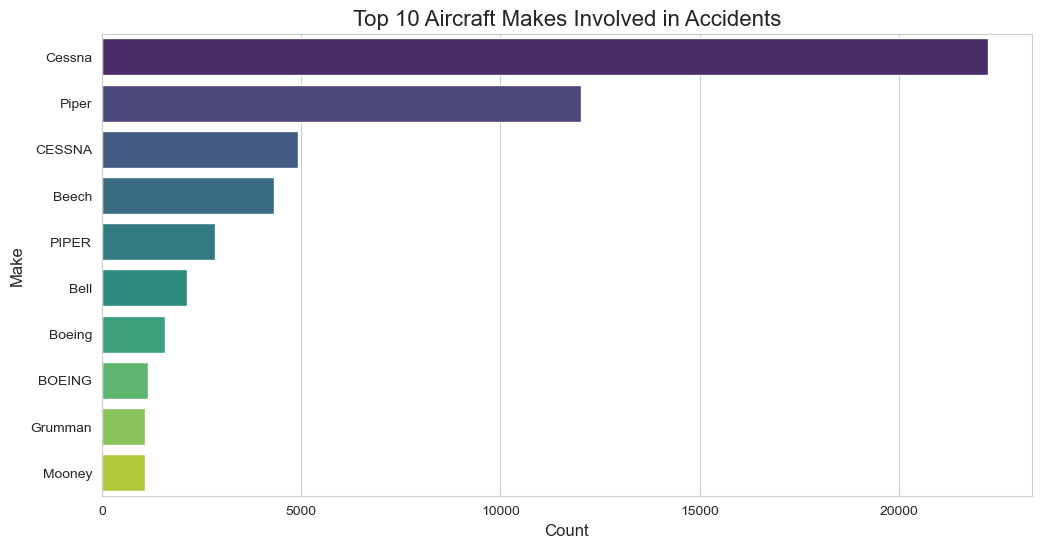

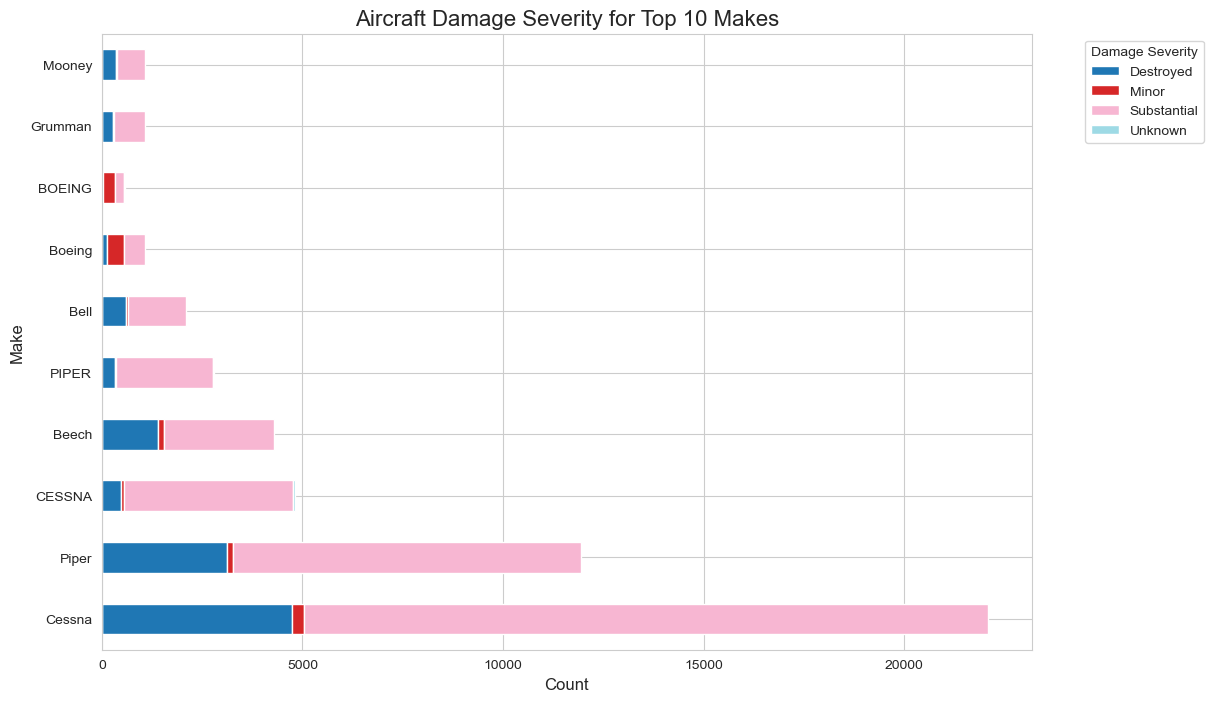

In [26]:
# 8. Aircraft Make and Model Analysis

# Top 10 Makes involved in accidents
top_makes = df['Make'].value_counts().head(10).index
make_df = df[df['Make'].isin(top_makes)]

# Plot Top 10 Makes
plt.figure(figsize=(12, 6))
sns.countplot(data=make_df, y='Make', order=top_makes, palette='viridis')
plt.title('Top 10 Aircraft Makes Involved in Accidents', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Make', fontsize=12)
plt.show()

# Analyze Damage for Top Makes
damage_counts = make_df.groupby(['Make', 'Aircraft.damage']).size().unstack(fill_value=0)
# Reorder index to match top_makes
damage_counts = damage_counts.reindex(top_makes)

# Stacked Horizontal Bar Chart
damage_counts.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='tab20')
plt.title('Aircraft Damage Severity for Top 10 Makes', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Make', fontsize=12)
plt.legend(title='Damage Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Analysis: Aircraft Make and Model
These charts identify the most common aircraft involved in accidents and the severity of damage they sustain.
*   **Top Makes:** Cessna and Piper are the most frequently involved manufacturers. This is expected as they are the most popular aircraft for general aviation and training.
*   **Damage Severity:** The second chart reveals that for these top makes, 'Substantial' damage is the most common outcome. 'Destroyed' aircraft represent a smaller but significant portion.
*   **Context:** High accident counts for these manufacturers do not necessarily imply they are unsafe; rather, it reflects their ubiquity in the fleet and their usage in flight training environments where risks are inherently higher.

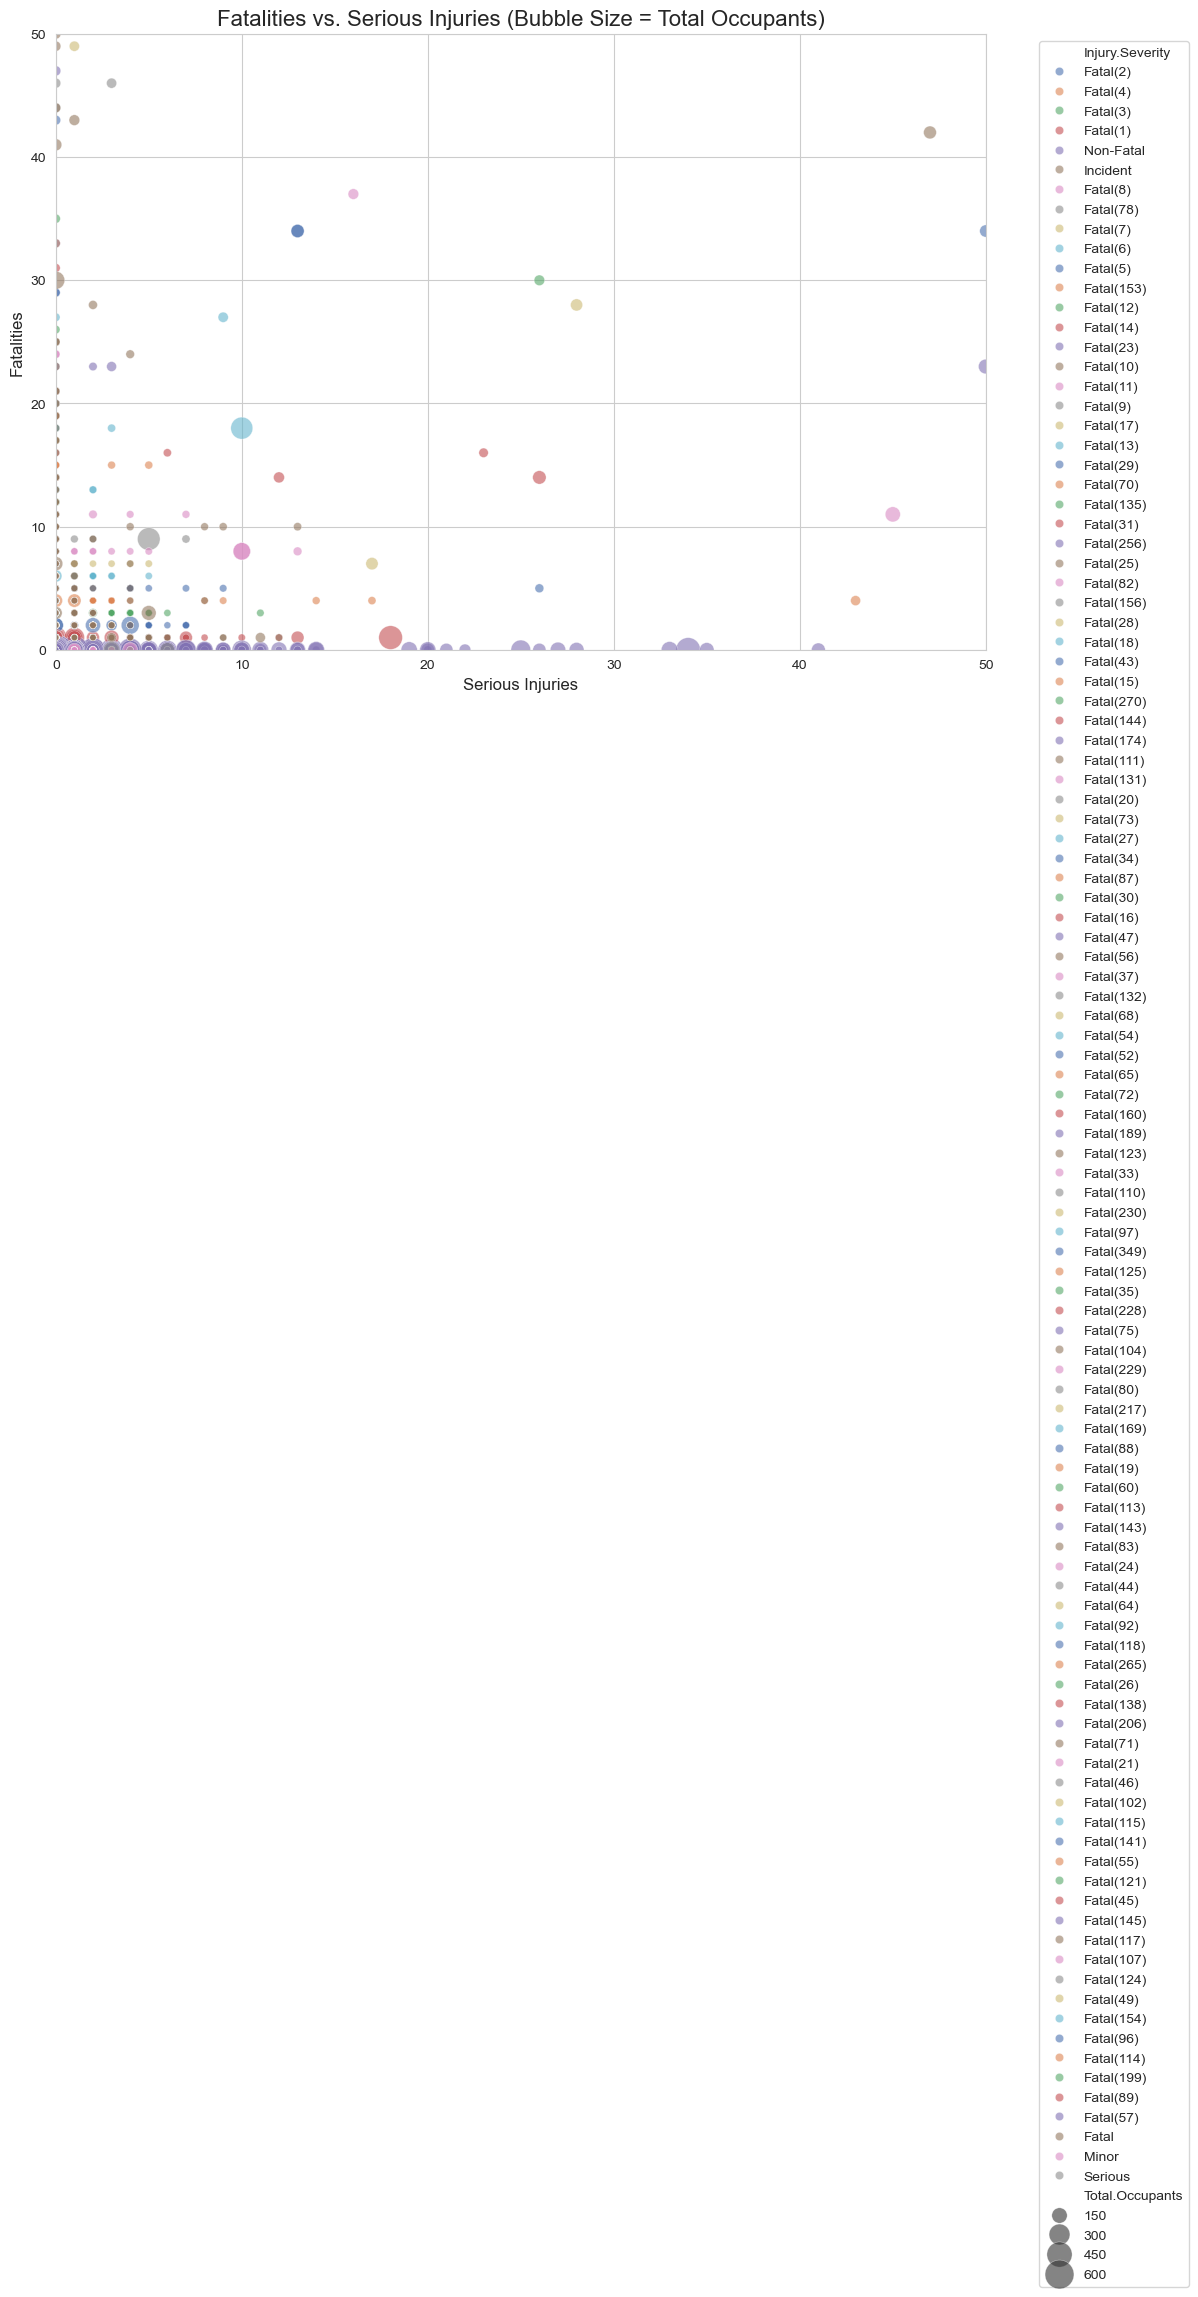

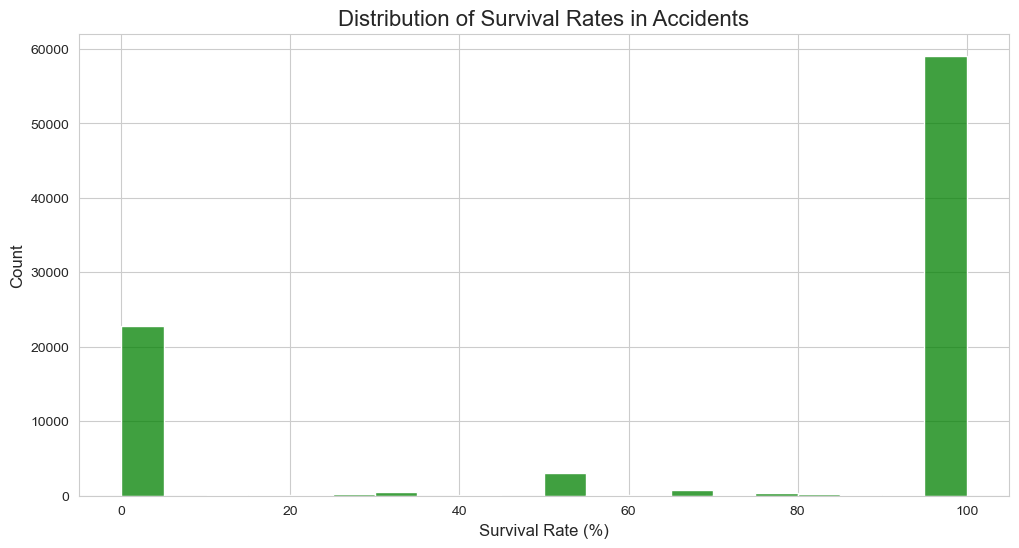

In [27]:
# 9. Survival Rates and Injury Analysis

# Filter out rows where Total.Occupants is 0 or NaN
survival_df = df[df['Total.Occupants'] > 0].copy()

# Calculate Survival Rate
survival_df['Survival_Rate'] = (survival_df['Total.Uninjured'] + survival_df['Total.Minor.Injuries']) / survival_df['Total.Occupants'] * 100

# Scatter Plot: Fatalities vs Serious Injuries
plt.figure(figsize=(12, 8))
# Use size for Total Occupants, hue for Injury Severity
sns.scatterplot(data=survival_df, x='Total.Serious.Injuries', y='Total.Fatal.Injuries', 
                size='Total.Occupants', hue='Injury.Severity', sizes=(20, 500), alpha=0.6, palette='deep')

plt.title('Fatalities vs. Serious Injuries (Bubble Size = Total Occupants)', fontsize=16)
plt.xlabel('Serious Injuries', fontsize=12)
plt.ylabel('Fatalities', fontsize=12)
plt.xlim(0, 50)
plt.ylim(0, 50)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Histogram of Survival Rates
plt.figure(figsize=(12, 6))
sns.histplot(survival_df['Survival_Rate'], bins=20, kde=False, color='green')
plt.title('Distribution of Survival Rates in Accidents', fontsize=16)
plt.xlabel('Survival Rate (%)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

### Analysis: Survival and Injury
The final set of charts explores the human cost of aviation accidents.
*   **Survival Rates:** The histogram shows a bimodal distribution. Accidents tend to be either highly survivable (near 100% survival rate) or fatal (0% survival rate). This "all or nothing" nature is characteristic of aviation incidents.
*   **Fatalities vs. Injuries:** The bubble chart shows that while many accidents result in minor or no injuries (clustered near the origin), there are distinct events with high fatalities. The size of the bubbles (total occupants) helps visualize the scale of the accident.
*   **Final Thought:** While aviation is statistically safe, the data shows that when safety barriers fail, the consequences can be severe. Continuous improvement in pilot training, weather forecasting, and technology is essential to mitigate these remaining risks.